Inspect one single DICOM along with all its metadata

File: data\raw\inbreast\ALL-IMGS\22427705_d713ef5849f98b6c_MG_L_CC_ANON.dcm


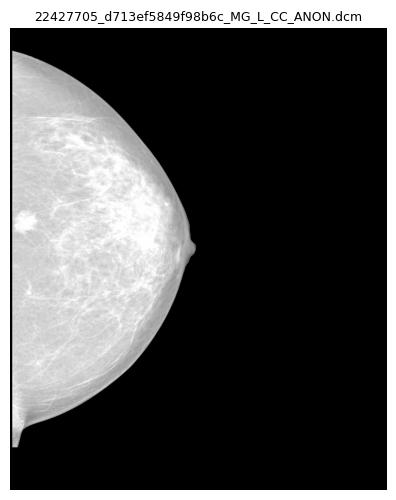

,tag,keyword,vr,name,value
0,"(0008,0016)",SOPClassUID,UI,SOP Class UID,1.2.840.10008.5.1.4.1.1.7
1,"(0008,0018)",SOPInstanceUID,UI,SOP Instance UID,1.3.6.1.4.1.9590.100.1.1.230418120812595497207...
2,"(0008,0020)",StudyDate,DA,Study Date,
3,"(0008,0023)",ContentDate,DA,Content Date,20111229
4,"(0008,0030)",StudyTime,TM,Study Time,
5,"(0008,0033)",ContentTime,TM,Content Time,220054.702995
6,"(0008,0050)",AccessionNumber,SH,Accession Number,
7,"(0008,0060)",Modality,CS,Modality,OT
8,"(0008,0064)",ConversionType,CS,Conversion Type,WSD
9,"(0008,0090)",ReferringPhysicianName,PN,Referring Physician's Name,


In [1]:
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ---- pick ONE file (edit this path if you want a specific one) ----
dicom_path = Path("data/raw/inbreast/ALL-IMGS")
dicom_path = next(dicom_path.glob("*.dcm"))  # first .dcm found
print("File:", dicom_path)

# ---- read DICOM ----
ds = pydicom.dcmread(str(dicom_path))

# ---- image for viewing ----
img = ds.pixel_array.astype(np.float32)

# VOI LUT (if present)
try:
    img = apply_voi_lut(img, ds).astype(np.float32)
except Exception:
    pass

# handle inversion
if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
    img = img.max() - img

# robust normalisation to [0,1]
lo, hi = np.percentile(img, (1, 99))
img = np.clip(img, lo, hi)
img = (img - lo) / (hi - lo + 1e-8)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(dicom_path.name, fontsize=9)
plt.axis("off")
plt.show()

# ---- ALL metadata as a table ----
rows = []
for elem in ds.iterall():
    tag = str(elem.tag)
    keyword = elem.keyword
    vr = elem.VR
    name = elem.name
    if keyword == "PixelData":
        try:
            value = f"<PixelData: {len(elem.value)} bytes>"
        except Exception:
            value = "<PixelData>"
    else:
        s = str(elem.value)
        if len(s) > 200:
            s = s[:200] + "..."
        value = s
    rows.append((tag, keyword, vr, name, value))

meta_df = pd.DataFrame(rows, columns=["tag", "keyword", "vr", "name", "value"])
display(meta_df)

Nothing useful in the metadata? 

View a random sample of 25

Showing 25 random DICOMs from: \\wsl$\Ubuntu\home\nabeel\project34\Project34\data\raw\inbreast\ALL-IMGS


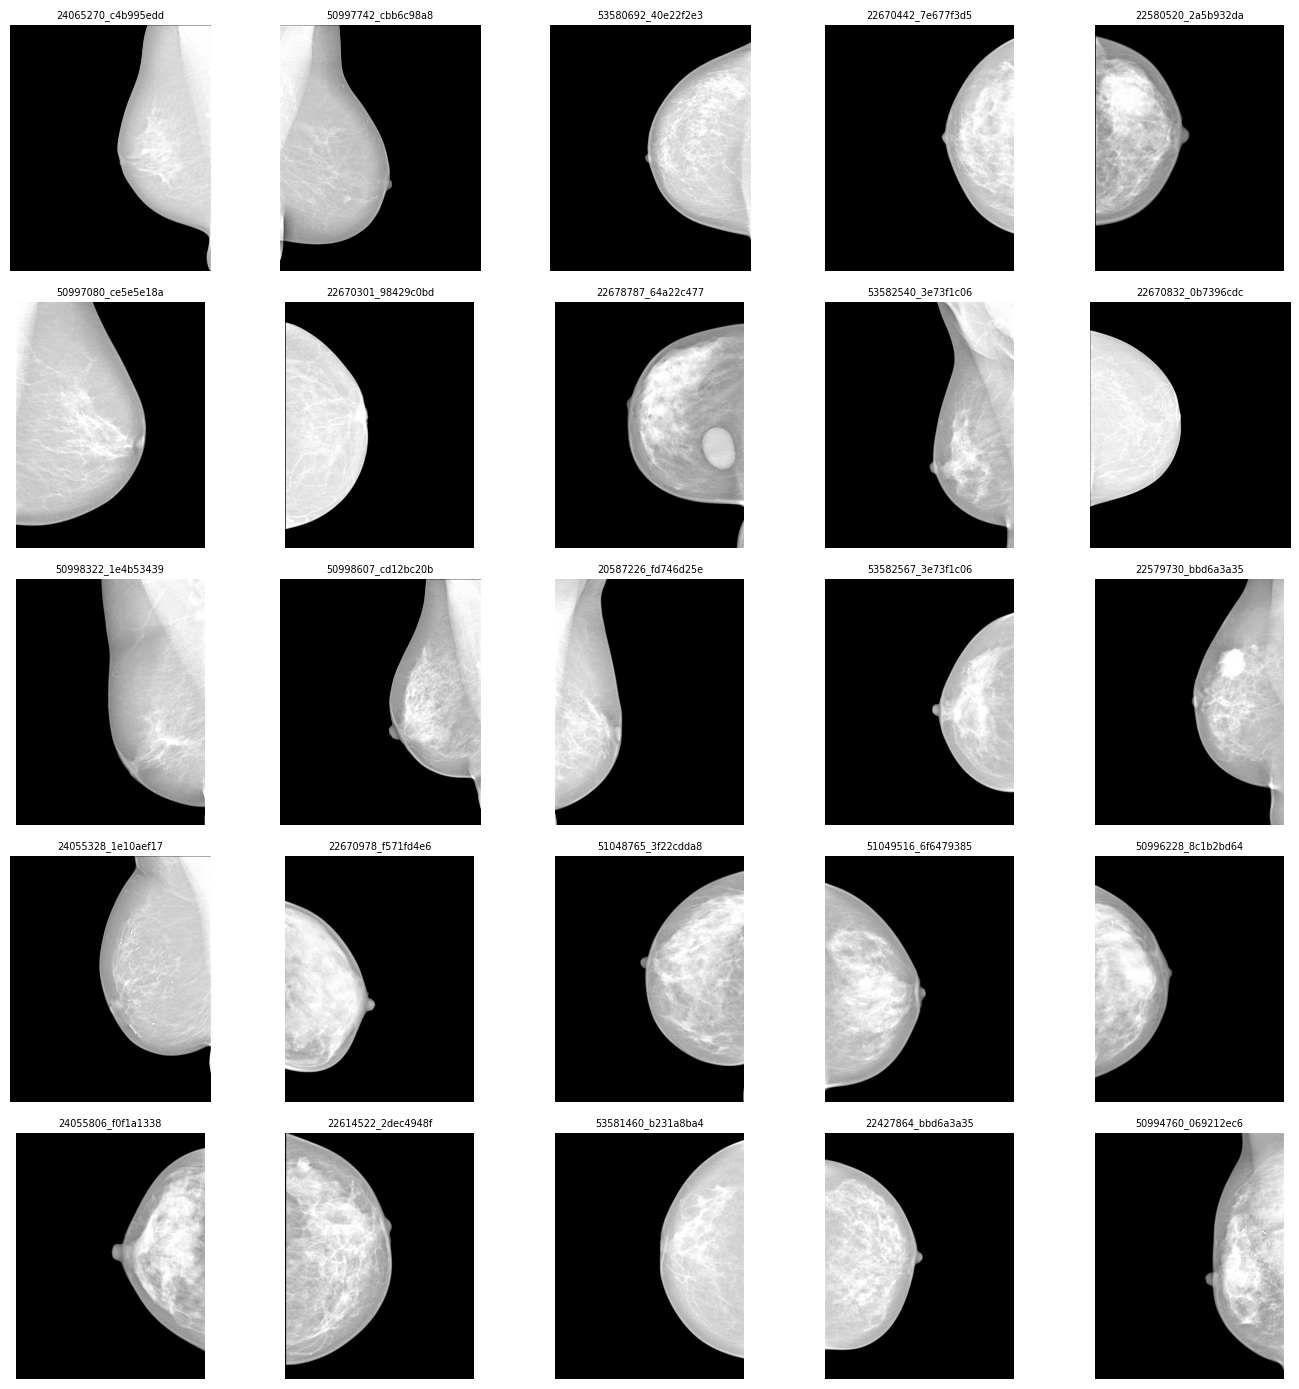

In [2]:
import random
from pathlib import Path

import numpy as np
import pydicom
import matplotlib.pyplot as plt
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ---- CONFIG ----
IMG_DIR = Path("data/raw/inbreast/ALL-IMGS")
N = 25  # number of random images to show
FIGSIZE = (14, 14)  # overall figure size
# ----------------

def load_for_display(dicom_path: Path) -> np.ndarray:
    ds = pydicom.dcmread(str(dicom_path))
    img = ds.pixel_array.astype(np.float32)

    # VOI LUT if present
    try:
        img = apply_voi_lut(img, ds).astype(np.float32)
    except Exception:
        pass

    # invert if needed
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # robust normalisation to [0,1]
    lo, hi = np.percentile(img, (1, 99))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img

dicoms = list(IMG_DIR.glob("*.dcm"))
if not dicoms:
    raise FileNotFoundError(f"No .dcm files found in {IMG_DIR.resolve()}")

sample = random.sample(dicoms, k=min(N, len(dicoms)))
print(f"Showing {len(sample)} random DICOMs from: {IMG_DIR.resolve()}")

plt.figure(figsize=FIGSIZE)

for i, p in enumerate(sample, 1):
    try:
        img = load_for_display(p)
        plt.subplot(5, 5, i)
        plt.imshow(img, cmap="gray")
        plt.title(p.name[:18], fontsize=7)
        plt.axis("off")
    except Exception as e:
        plt.subplot(5, 5, i)
        plt.text(0.5, 0.5, f"Error\n{p.name}\n{type(e).__name__}", ha="center", va="center", fontsize=7)
        plt.axis("off")

plt.tight_layout()
plt.show()